<a href="https://colab.research.google.com/github/Borracheira/gravitacional-wave/blob/main/TFA_STFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

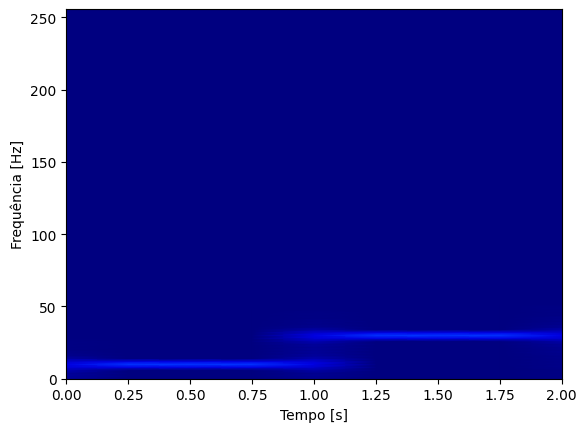

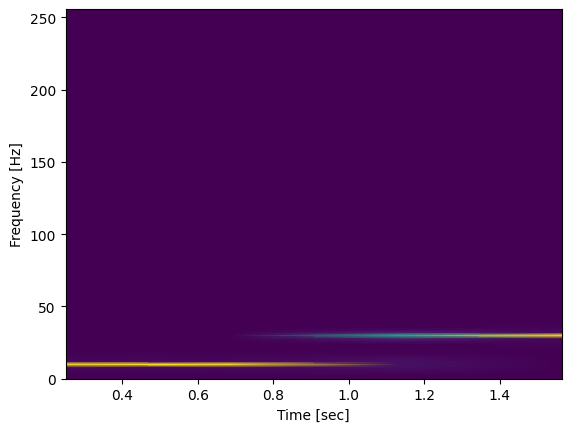

In [ ]:
#essas linhas importam as bibliotecas necessárias.
import numpy as np #numpy para operações numéricas
from scipy import signal #scipy.signal é para funções de processamento de sinais (como gerações de chirps e STFT)
import matplotlib.pyplot as plt #matplotlib.pyplot para criação de gráficos

t, dt = np.linspace(0, 2, 1024, retstep=True) #vetor tempo
Fs = 1/dt #frequência de amostragem

#frequência em Hertz
freq1=10
freq2=30
#gera um sinal senoidal. Sinal estacionário (freq nao muda com o tempo)
y1=np.sin(2*np.pi*freq1*t)
y2=1.5*np.sin(2*np.pi*freq1*t) + 2*np.sin(2*np.pi*freq2*t)
#sinal não estacionário, freq muda abruptamente no tempo
y3= np.piecewise(t, [t < 1, t > 1],[lambda t:
                                    np.sin(2 * np.pi * freq1 * t),
                                    lambda t:
                                    np.sin(2 * np.pi * freq2 * t)])

y4=signal.chirp(t, f0=0, f1=50, t1=2, method='linear')


amp = 2 * np.sqrt(2)

#Função principal para a transformada de fourier de curto prazo STFT.
#pega o sinal de y3 e a frequencia de amostragem Fs e o divide em pequenas janelas de tempo.
f, T_STFT, Zxx = signal.stft(y3, Fs)
plt.figure()
plt.pcolormesh(T_STFT, f, np.abs(Zxx), vmin=0, vmax=amp,cmap='jet',shading='gouraud')
plt.xlabel('Tempo [s]')
plt.ylabel('Frequência [Hz]')
plt.show()

#Fisicamente, o gráfico mostra o tempo (eixo x) e as frequências Hz presentes no sinal (eixo y)


f, t, Sxx = signal.spectrogram(y3, Fs)
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [ ]:
Fs

np.float64(511.5)

In [ ]:
try:
    with open('/content/.config/configurations/config_default', 'r') as file_obj:
        stft_window_types = file_obj.read()
    print(stft_window_types)
except FileNotFoundError:
    print("The file '/content/.config/configurations/config_default' was not found. Please check the file path and name.")


[component_manager]
disable_update_check = true

[compute]
gce_metadata_read_timeout_sec = 0




### Exploring Different STFT Window Types

We will now apply various window functions to the Short-Time Fourier Transform (STFT) of the `y4` signal. Different window functions can affect the trade-off between spectral leakage and frequency resolution. We will visualize the spectrogram for each window type to observe these differences.

Applying STFT with the following window types: hann, hamming, blackman, boxcar


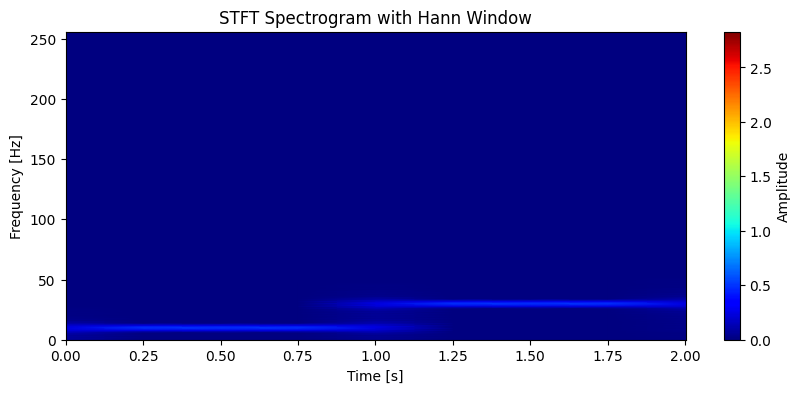

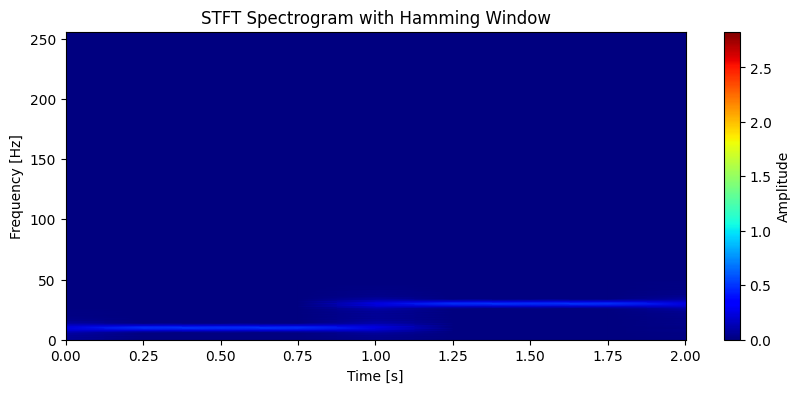

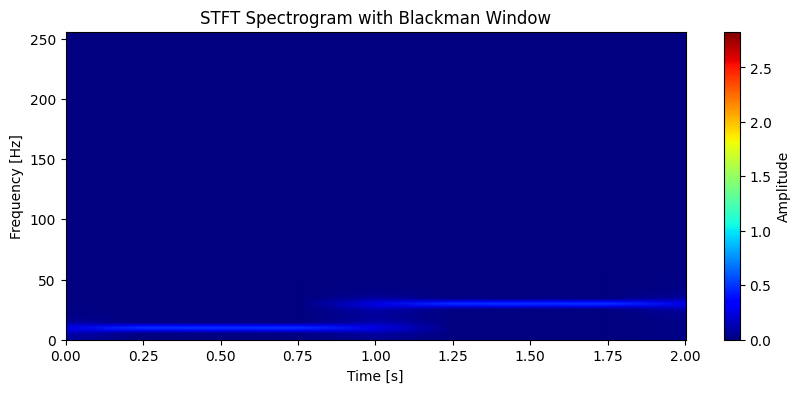

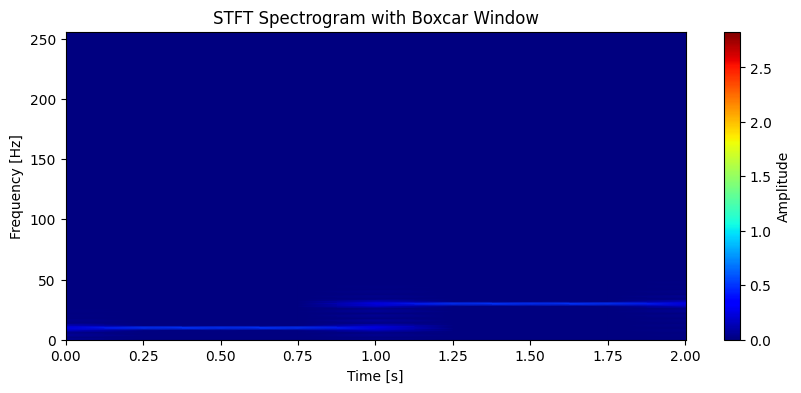

In [ ]:
window_names = ['hann', 'hamming', 'blackman', 'boxcar'] #janelas utilizadas

print(f"Applying STFT with the following window types: {', '.join(window_names)}")

for window_name in window_names:
    try:
        # Calculate STFT for each window type
        f_stft, T_STFT, Zxx_windowed = signal.stft(y3, Fs, window=window_name)

        # Plotting the spectrogram
        plt.figure(figsize=(10, 4))
        plt.pcolormesh(T_STFT, f_stft, np.abs(Zxx_windowed), vmin=0, vmax=amp, cmap='jet', shading='gouraud')
        plt.title(f'STFT Spectrogram with {window_name.capitalize()} Window')
        plt.xlabel('Time [s]')
        plt.ylabel('Frequency [Hz]')
        plt.colorbar(label='Amplitude')
        plt.show()
    except ValueError as e:
        print(f"Could not apply '{window_name}' window: {e}. Skipping this window type.")
    except Exception as e:
        print(f"An unexpected error occurred for window '{window_name}': {e}. Skipping this window type.")


Applying STFT with the following additional window types: gaussian, barthann, flattop, triang
Could not apply 'gaussian' window: The 'gaussian' window needs one or more parameters -- pass a tuple.. Skipping this window type.


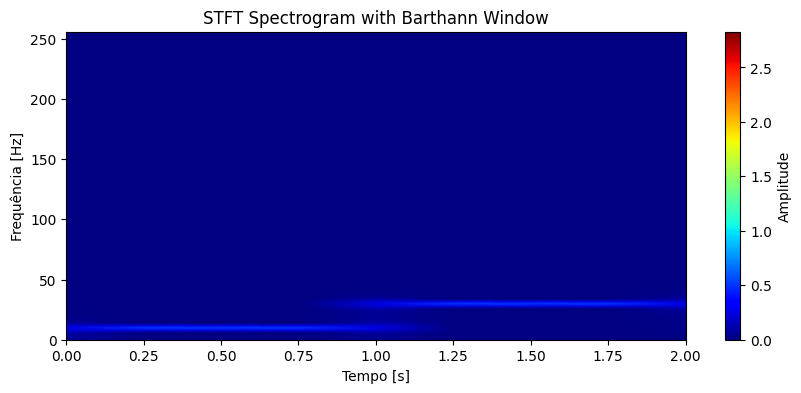

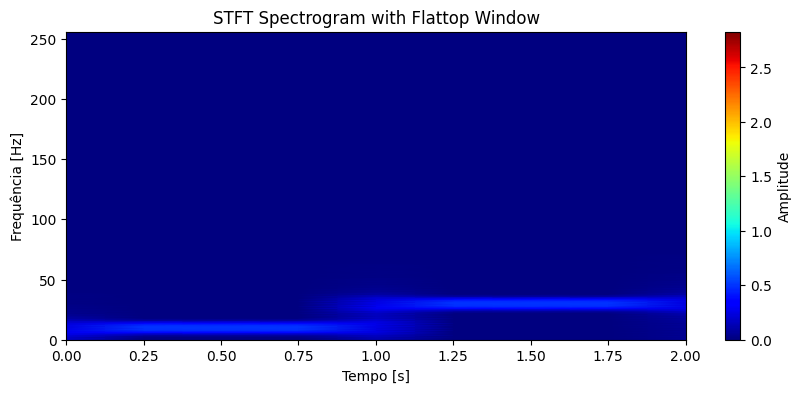

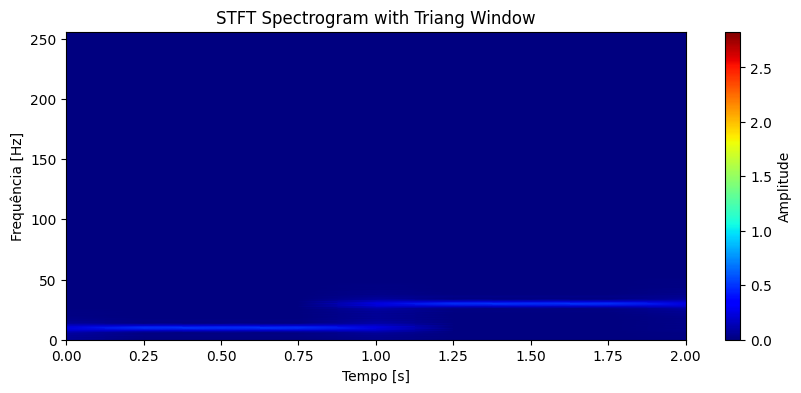

In [ ]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

t, dt = np.linspace(0, 2, 1024, retstep=True)
Fs = 1/dt

freq1=10
freq2=30

# Sinal y3 (nao estacionário)
y3 = np.piecewise(t, [t < 1, t > 1],[lambda t: np.sin(2 * np.pi * freq1 * t), lambda t: np.sin(2 * np.pi * freq2 * t)])

amp = 2 * np.sqrt(2) # Amplitude

additional_window_names = ['gaussian', 'barthann', 'flattop', 'triang']

print(f"Applying STFT with the following additional window types: {', '.join(additional_window_names)}")

for window_name in additional_window_names:
    try:

        if window_name == 'gaussian':
            f_stft, T_STFT, Zxx_windowed = signal.stft(y3, Fs, window=window_name)
        else:
            f_stft, T_STFT, Zxx_windowed = signal.stft(y3, Fs, window=window_name)

        plt.figure(figsize=(10, 4))
        plt.pcolormesh(T_STFT, f_stft, np.abs(Zxx_windowed), vmin=0, vmax=amp, cmap='jet', shading='gouraud')
        plt.title(f'STFT Spectrogram with {window_name.capitalize()} Window')
        plt.xlabel('Tempo [s]')
        plt.ylabel('Frequência [Hz]')
        plt.colorbar(label='Amplitude')
        plt.show()
    except ValueError as e:
        print(f"Could not apply '{window_name}' window: {e}. Skipping this window type.")
    except Exception as e:
        print(f"An unexpected error occurred for window '{window_name}': {e}. Skipping this window type.")